In [2]:
import re
import unicodedata
import random
from collections import Counter, defaultdict
from typing import List, Dict, Tuple, Iterable

import pandas as pd
import matplotlib.pyplot as plt


# Languages and rules

In [3]:
LANG_CODES = ["de", "en", "es", "fr", "it", "ko", "pt", "ta", "be", "ru"]

LANG_RULES: Dict[str, Dict] = {
    "en": {
        "name": "English",
        "script": "latin",
        "stopwords": {
            "the", "and", "of", "to", "in", "is", "for",
            "on", "with", "that", "this", "it", "as", "at"
        },
        "special_chars": set(),
        "bigrams": set(),
        "trigrams": set(),
        "fourgrams": set(),
    },
    "de": {
        "name": "German",
        "script": "latin",
        "stopwords": {
            "der", "die", "das", "und", "nicht", "ist",
            "ein", "eine", "im", "mit", "für", "auf"
        },
        "special_chars": {"ä", "ö", "ü", "ß"},
        "bigrams": set(),
        "trigrams": set(),
        "fourgrams": set(),
    },
    "es": {
        "name": "Spanish",
        "script": "latin",
        "stopwords": {
            "el", "la", "los", "las",
            "del", "al",
            "que", "porque", "como",
            "una", "uno",
            "sí", "pero"
        },
        "special_chars": {"ñ"},
        "bigrams": set(),
        "trigrams": set(),
        "fourgrams": set(),
    },
    "fr": {
        "name": "French",
        "script": "latin",
        "stopwords": {
            "le", "la", "les",
            "de", "des",
            "un", "une",
            "et", "est",
            "pour", "sur",
            "au", "aux",
            "pas", "ces", "cette"
        },
        "special_chars": {"é", "è", "ê", "à", "ç", "ù", "ô"},
        "bigrams": set(),
        "trigrams": set(),
        "fourgrams": set(),
    },
    "it": {
        "name": "Italian",
        "script": "latin",
        "stopwords": {
            "il", "lo", "la", "i", "gli", "le",
            "di", "che", "per", "con", "nel",
            "della", "dello"
        },
        "special_chars": {"à", "è", "é", "ì", "ò", "ù"},
        "bigrams": set(),
        "trigrams": set(),
        "fourgrams": set(),
    },
    "pt": {
        "name": "Portuguese",
        "script": "latin",
        "stopwords": {
            "o", "a", "os", "as",
            "do", "da", "dos", "das",
            "que", "em", "para", "por",
            "não", "também", "nos", "nas"
        },
        "special_chars": {"ã", "õ"},
        "bigrams": set(),
        "trigrams": set(),
        "fourgrams": set(),
    },
    "ko": {
        "name": "Korean",
        "script": "hangul",
        "stopwords": {
            "이", "그", "저", "그리고", "하지만", "에서", "에게", "이다"
        },
        "special_chars": set(),
        "bigrams": set(),
        "trigrams": set(),
        "fourgrams": set(),
    },
    "ta": {
        "name": "Tamil",
        "script": "tamil",
        "stopwords": {
            "ஒரு", "இந்த", "அது", "இல்", "மற்றும்", "என்று"
        },
        "special_chars": set(),
        "bigrams": set(),
        "trigrams": set(),
        "fourgrams": set(),
    },
    "ru": {
        "name": "Russian",
        "script": "cyrillic",
        "stopwords": {
            "что", "это", "чтобы", "которые", "который",
            "или", "если", "потому", "также",
            "будет", "были", "может", "нужно"
        },
        "special_chars": {"ъ", "ы", "э"},
        "bigrams": set(),
        "trigrams": set(),
        "fourgrams": set(),
    },
    "be": {
        "name": "Belarusian",
        "script": "cyrillic",
        "stopwords": {
            "і", "што", "ён", "яна",
            "як", "з", "па", "гэта", "калі", "каб", "яшчэ", "таму",
            "яны", "які", "якая", "якое", "якія", "нібыта"
        },
        "special_chars": {"ў", "і"},
        "bigrams": set(),
        "trigrams": set(),
        "fourgrams": set(),
    },
}


# Script recognizing, tokenization (for letters separately), n-grams, extra cleaning

In [4]:
def detect_script(text: str) -> str:
    has_cyr = has_lat = has_hangul = has_tamil = False

    for ch in text:
        if not ch.isalpha():
            continue
        name = unicodedata.name(ch, "")
        if "CYRILLIC" in name:
            has_cyr = True
        elif "LATIN" in name:
            has_lat = True
        elif "HANGUL" in name:
            has_hangul = True
        elif "TAMIL" in name:
            has_tamil = True

    flags = [has_cyr, has_lat, has_hangul, has_tamil]
    if sum(flags) == 1:
        if has_cyr:
            return "cyrillic"
        if has_lat:
            return "latin"
        if has_hangul:
            return "hangul"
        if has_tamil:
            return "tamil"
    return "mixed"


WORD_RE = re.compile(r"[^\W\d_]+", re.UNICODE)

def tokenize(text: str) -> List[str]:
    return [w.lower() for w in WORD_RE.findall(text)]


def char_ngrams(text: str, n: int) -> Counter:
    text = text.lower()
    chars = [c for c in text if c.isalpha()]
    grams = ["".join(chars[i:i + n]) for i in range(len(chars) - n + 1)]
    return Counter(grams)


def clean_text_basic(text: str) -> str:
    cleaned_chars = []
    for ch in text:
        if ch.isalpha() or ch.isspace():
            cleaned_chars.append(ch)
        else:
            cleaned_chars.append(" ")
    text = "".join(cleaned_chars)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


# Preprocessed data uploading from .conllu files

In [5]:
def load_conllu_sentences(path: str) -> List[str]:
    sentences = []
    current_tokens: List[str] = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.rstrip("\n")

            if not line:
                if current_tokens:
                    sent = " ".join(current_tokens)
                    sent = clean_text_basic(sent)
                    if sent:
                        sentences.append(sent)
                    current_tokens = []
                continue

            if line.startswith("#"):
                continue

            cols = line.split("\t")
            if len(cols) >= 2:
                token = cols[1]
                current_tokens.append(token)

    if current_tokens:
        sent = " ".join(current_tokens)
        sent = clean_text_basic(sent)
        if sent:
            sentences.append(sent)

    return sentences


def load_corpus_from_dir(
    data_dir: str,
    max_sent_per_lang: int = 100_000
) -> Tuple[List[str], List[str]]:
    texts, labels = [], []
    for lang in LANG_CODES:
        path = f"{data_dir}/output_{lang}.conllu"
        try:
            sents = load_conllu_sentences(path)
        except FileNotFoundError:
            print(f"WARNING: file not found for language {lang}: {path}")
            continue

        if max_sent_per_lang is not None:
            sents = sents[:max_sent_per_lang]

        texts.extend(sents)
        labels.extend([lang] * len(sents))

    return texts, labels


# n-grams building and recording to language rules (LANG_RULES)

In [6]:
def build_char_ngrams_from_corpus(
    texts: Iterable[str],
    labels: Iterable[str],
    n: int,
    top_k: int = 30,
    min_freq: int = 5,
) -> Dict[str, List[str]]:
    per_lang_counts: Dict[str, Counter] = defaultdict(Counter)

    for text, lang in zip(texts, labels):
        grams = char_ngrams(text, n)
        per_lang_counts[lang].update(grams)

    result: Dict[str, List[str]] = {}
    for lang, counter in per_lang_counts.items():
        filtered = Counter({g: c for g, c in counter.items() if c >= min_freq})
        result[lang] = [g for g, _ in filtered.most_common(top_k)]
    return result


def init_ngram_rules(
    texts: Iterable[str],
    labels: Iterable[str],
    bigram_top_k: int = 30,
    trigram_top_k: int = 30,
    fourgram_top_k: int = 30,
) -> None:
    bigrams = build_char_ngrams_from_corpus(texts, labels, n=2, top_k=bigram_top_k)
    trigrams = build_char_ngrams_from_corpus(texts, labels, n=3, top_k=trigram_top_k)
    fourgrams = build_char_ngrams_from_corpus(texts, labels, n=4, top_k=fourgram_top_k)

    for lang, rules in LANG_RULES.items():
        if lang in bigrams:
            rules["bigrams"] = set(bigrams[lang])
        if lang in trigrams:
            rules["trigrams"] = set(trigrams[lang])
        if lang in fourgrams:
            rules["fourgrams"] = set(fourgrams[lang])


# Weights for choosing the best parameters

In [7]:
WEIGHT_SETS = {
    "base": {
        "stop": 3.0,
        "special": 4.0,
        "bi": 1.0,
        "tri": 2.0,
        "four": 3.0,
    },
    "strong_ngrams": {
        "stop": 2.0,
        "special": 3.0,
        "bi": 1.5,
        "tri": 3.0,
        "four": 4.0,
    },
    "strong_special": {
        "stop": 2.0,
        "special": 6.0,
        "bi": 1.0,
        "tri": 2.0,
        "four": 3.0,
    },
}


# Scoring rules

In [8]:
def score_language(text: str, lang_code: str, weights: Dict[str, float]) -> float:
    rules = LANG_RULES[lang_code]
    tokens = tokenize(text)
    bigram_counts = char_ngrams(text, 2)
    trigram_counts = char_ngrams(text, 3)
    fourgram_counts = char_ngrams(text, 4)

    score = 0.0

    # stop words
    sw = rules.get("stopwords", set())
    for tok in tokens:
        if tok in sw:
            score += weights["stop"]

    # special symbols
    specials = rules.get("special_chars", set())
    for ch in text.lower():
        if ch in specials:
            score += weights["special"]

    # 2-grams
    for gram in rules.get("bigrams", set()):
        score += weights["bi"] * bigram_counts.get(gram, 0)

    # 3-grams
    for gram in rules.get("trigrams", set()):
        score += weights["tri"] * trigram_counts.get(gram, 0)

    # 4-grams
    for gram in rules.get("fourgrams", set()):
        score += weights["four"] * fourgram_counts.get(gram, 0)

    return score


# Predicting, evaluating

In [9]:
def predict_language(text: str, weights: Dict[str, float]) -> str:
    script = detect_script(text)

    candidates = []
    for code, cfg in LANG_RULES.items():
        if script == "mixed":
            candidates.append(code)
        elif cfg["script"] == script:
            candidates.append(code)

    if not candidates:
        candidates = list(LANG_RULES.keys())

    if len(candidates) == 1:
        return candidates[0]

    scores = {code: score_language(text, code, weights) for code in candidates}
    best_lang, best_score = max(scores.items(), key=lambda x: x[1])

    if best_score == 0:
        return "unknown"
    return best_lang


def evaluate(texts: List[str], labels: List[str], weights: Dict[str, float]) -> Tuple[float, Counter]:
    assert len(texts) == len(labels)
    correct = 0
    conf = Counter()
    for t, gold in zip(texts, labels):
        pred = predict_language(t, weights)
        if pred == gold:
            correct += 1
        conf[(gold, pred)] += 1
    acc = correct / len(texts) if texts else 0.0
    return acc, conf


def train_test_split(texts: List[str], labels: List[str], test_ratio: float = 0.2, seed: int = 42):
    idx = list(range(len(texts)))
    random.Random(seed).shuffle(idx)
    cut = int(len(idx) * (1 - test_ratio))
    train_idx = idx[:cut]
    test_idx = idx[cut:]
    train_texts = [texts[i] for i in train_idx]
    train_labels = [labels[i] for i in train_idx]
    test_texts = [texts[i] for i in test_idx]
    test_labels = [labels[i] for i in test_idx]
    return train_texts, train_labels, test_texts, test_labels


Check

In [10]:
DATA_DIR = "preprocessing/data"

texts, labels = load_corpus_from_dir(DATA_DIR, max_sent_per_lang=100_000)
print("Total sentences:", len(texts))

train_texts, train_labels, test_texts, test_labels = train_test_split(
    texts, labels, test_ratio=0.2
)

init_ngram_rules(
    train_texts,
    train_labels,
    bigram_top_k=30,
    trigram_top_k=30,
    fourgram_top_k=30,
)

weights = WEIGHT_SETS["base"]
acc, conf = evaluate(test_texts, test_labels, weights)
print("Accuracy (base):", acc)


Total sentences: 1000000
Accuracy (base): 0.930215


# Running

In [11]:
def run_experiment(
    data_dir: str,
    max_sent_per_lang: int,
    top_k: int,
    weight_name: str,
    test_ratio: float = 0.2,
    seed: int = 42,
) -> Tuple[float, Counter, int]:
    # loading corpus subset
    texts, labels = load_corpus_from_dir(data_dir, max_sent_per_lang=max_sent_per_lang)

    train_texts, train_labels, test_texts, test_labels = train_test_split(
        texts, labels, test_ratio=test_ratio, seed=seed
    )

    # n-grams learning
    init_ngram_rules(
        train_texts,
        train_labels,
        bigram_top_k=top_k,
        trigram_top_k=top_k,
        fourgram_top_k=top_k,
    )

    weights = WEIGHT_SETS[weight_name]
    acc, conf = evaluate(test_texts, test_labels, weights)

    return acc, conf, len(test_texts)


Best parameter search

In [12]:
DATA_DIR = "preprocessing/data"

max_sents_grid = [50_000, 100_000, 150_000, 200_000]  # если данных меньше – лишние просто урежутся
top_k_grid = [20, 30, 40]
weight_names = list(WEIGHT_SETS.keys())

results = []
confusions_by_config = {}

for max_sent in max_sents_grid:
    for top_k in top_k_grid:
        for w_name in weight_names:
            print(f"Running: max_sent={max_sent}, top_k={top_k}, weights={w_name}")
            acc, conf, n_test = run_experiment(DATA_DIR, max_sent, top_k, w_name)
            cfg_id = (max_sent, top_k, w_name)
            results.append({
                "max_sent_per_lang": max_sent,
                "top_k": top_k,
                "weights": w_name,
                "accuracy": acc,
                "n_test": n_test,
            })
            confusions_by_config[cfg_id] = conf

results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values("accuracy", ascending=False)
results_df_sorted


Running: max_sent=50000, top_k=20, weights=base
Running: max_sent=50000, top_k=20, weights=strong_ngrams
Running: max_sent=50000, top_k=20, weights=strong_special
Running: max_sent=50000, top_k=30, weights=base
Running: max_sent=50000, top_k=30, weights=strong_ngrams
Running: max_sent=50000, top_k=30, weights=strong_special
Running: max_sent=50000, top_k=40, weights=base
Running: max_sent=50000, top_k=40, weights=strong_ngrams
Running: max_sent=50000, top_k=40, weights=strong_special
Running: max_sent=100000, top_k=20, weights=base
Running: max_sent=100000, top_k=20, weights=strong_ngrams
Running: max_sent=100000, top_k=20, weights=strong_special
Running: max_sent=100000, top_k=30, weights=base
Running: max_sent=100000, top_k=30, weights=strong_ngrams
Running: max_sent=100000, top_k=30, weights=strong_special
Running: max_sent=100000, top_k=40, weights=base
Running: max_sent=100000, top_k=40, weights=strong_ngrams
Running: max_sent=100000, top_k=40, weights=strong_special
Running: max_

,max_sent_per_lang,top_k,weights,accuracy,n_test
6,50000,40,base,0.939160,100000
24,150000,40,base,0.937730,300000
15,100000,40,base,0.937525,200000
7,50000,40,strong_ngrams,0.935700,100000
8,50000,40,strong_special,0.934950,100000
16,100000,40,strong_ngrams,0.934245,200000
3,50000,30,base,0.934190,100000
25,150000,40,strong_ngrams,0.934173,300000
26,150000,40,strong_special,0.933093,300000
17,100000,40,strong_special,0.932765,200000


Plots Accuracy vs parameters, confusions

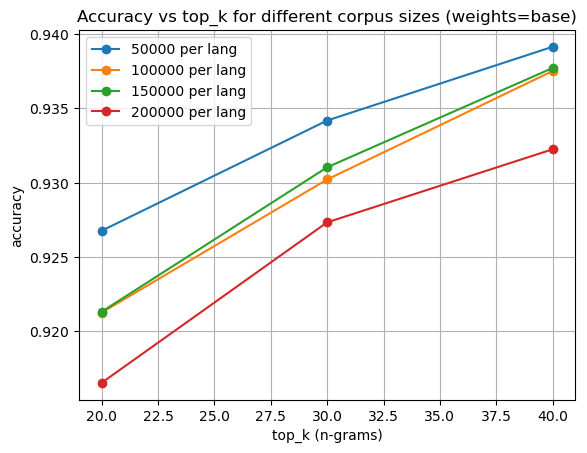

((50000, 40, 'base'), np.float64(0.93916))

In [13]:
base_results = results_df[results_df["weights"] == "base"]

plt.figure()
for max_sent in sorted(base_results["max_sent_per_lang"].unique()):
    subset = base_results[base_results["max_sent_per_lang"] == max_sent]
    subset = subset.sort_values("top_k")
    plt.plot(subset["top_k"], subset["accuracy"], marker="o", label=f"{max_sent} per lang")

plt.xlabel("top_k (n-grams)")
plt.ylabel("accuracy")
plt.title("Accuracy vs top_k for different corpus sizes (weights=base)")
plt.legend()
plt.grid(True)
plt.show()

best_row = results_df_sorted.iloc[0]
best_cfg = (
    int(best_row["max_sent_per_lang"]),
    int(best_row["top_k"]),
    best_row["weights"],
)
best_conf = confusions_by_config[best_cfg]
best_acc = best_row["accuracy"]
best_cfg, best_acc

In [14]:
error_rows = [
    {"gold": g, "pred": p, "count": c}
    for (g, p), c in best_conf.items()
    if g != p
]
errors_df = pd.DataFrame(error_rows).sort_values("count", ascending=False)
errors_df.head(20)


,gold,pred,count
6,be,ru,809
2,es,pt,725
4,es,en,339
13,de,en,337
9,pt,fr,297
7,pt,es,276
17,es,it,249
19,pt,en,214
10,pt,it,205
1,es,fr,200


In [15]:
conf_matrix_df = pd.DataFrame(
    0, index=LANG_CODES + ["unknown"], columns=LANG_CODES + ["unknown"]
)

for (g, p), c in best_conf.items():
    if g not in conf_matrix_df.index:
        conf_matrix_df.loc[g] = 0
    if p not in conf_matrix_df.columns:
        conf_matrix_df[p] = 0
    conf_matrix_df.loc[g, p] += c

conf_matrix_df


,de,en,es,fr,it,ko,pt,ta,be,ru,unknown
de,9426,337,31,76,91,0,49,0,0,0,8
en,121,9580,64,84,90,0,76,0,0,0,2
es,151,339,8163,200,249,0,725,0,0,0,17
fr,83,155,70,9440,161,0,46,0,0,0,3
it,101,152,154,107,9517,0,142,0,0,0,8
ko,0,0,0,0,0,9842,0,0,0,0,0
pt,104,214,276,297,205,0,8956,0,0,0,14
ta,0,0,0,0,0,0,0,10095,0,0,0
be,0,0,0,0,0,0,0,0,9096,809,41
ru,0,0,0,0,0,0,0,0,162,9801,70
